In [ ]:
# ! pip install scikit-learn

In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

%config InlineBackend.figure_format='retina'
xr.set_options(display_style="text")


In [3]:
# Load mean sea surface temperature dataset
ds_ref = xr.open_dataset("../../data/sst.oisst.mon.ltm.1991-2020.nc", engine="netcdf4")

ds = xr.open_dataset("../../data/sst.wkmean.1990-present.nc", engine="netcdf4") # 1727 but no countries

# xarray's HTML representation
ds_copy = ds.copy(deep=True)

/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_55120/4275862908.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds_ref = xr.open_dataset("../../data/sst.oisst.mon.ltm.1991-2020.nc", engine="netcdf4")
/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_55120/4275862908.py:2: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds_ref = xr.open_dataset("../../data/sst.oisst.mon.ltm.1991-2020.nc", engine="netcdf4")


In [4]:
indices = np.argwhere(np.isnan(ds_ref.sst[0].data))
for (idx_y, idx_x) in indices:
    ds.sst[dict(lat=-idx_y, lon=idx_x)] = np.nan

In [5]:
# Region of interest: mediteranean sea

min_coords = [20.5, 0.5] #latitute, longitude
max_coords = [50.5, 40.5]

da = ds.sst

In [6]:
min_lat_idx = int(np.where(da.lat.data==max_coords[0])[0])
max_lat_idx = int(np.where(da.lat.data==min_coords[0])[0])

min_lon_idx = int(np.where(da.lon.data==min_coords[1])[0])
max_lon_idx = int(np.where(da.lon.data==max_coords[1])[0])

data_sq = da.data[:, min_lat_idx:max_lat_idx+1, min_lon_idx:max_lon_idx+1]

print("min/max lat/lon values", min_lat_idx, max_lat_idx, min_lon_idx, max_lon_idx)
print("data shape: ", data_sq.shape) # time, lat, lon
## time points frequency is ~ [1,2] weeks 

min/max lat/lon values 39 69 0 40
data shape:  (1727, 31, 41)


/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_55120/3594888808.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  min_lat_idx = int(np.where(da.lat.data==max_coords[0])[0])
/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_55120/3594888808.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  max_lat_idx = int(np.where(da.lat.data==min_coords[0])[0])
/var/folders/k8/8bd2c6nd31s1yp4rsc4gj7340000gn/T/ipykernel_55120/3594888808.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this opera

In [7]:
sst_med_sea = ds.sst[:,min_lat_idx:max_lat_idx+1, min_lon_idx:max_lon_idx+1]
sst_med_sea.shape, ds.sst.shape

((1727, 31, 41), (1727, 180, 360))

1. Compute Monthly Climatology

In [8]:
sst_med_sea.time

<xarray.DataArray 'time' (time: 1727)> Size: 14kB
array(['1989-12-31T00:00:00.000000000', '1990-01-07T00:00:00.000000000',
       '1990-01-14T00:00:00.000000000', ..., '2023-01-15T00:00:00.000000000',
       '2023-01-22T00:00:00.000000000', '2023-01-29T00:00:00.000000000'],
      shape=(1727,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 14kB 1989-12-31 1990-01-07 ... 2023-01-29
Attributes:
    long_name:      Time
    actual_range:   [69395. 81477.]
    delta_t:        0000-00-07 00:00:00
    avg_period:     0000-00-07 00:00:00
    standard_name:  time
    axis:           T
    bounds:         time_bnds

In [9]:
sst_gb = sst_med_sea.groupby("time.month", )
print(sst_gb)

<DataArrayGroupBy, grouped over 1 grouper(s), 12 groups in total:
    'month': UniqueGrouper('month'), 12/12 groups with labels 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12>


In [10]:
sst_gb

<DataArrayGroupBy, grouped over 1 grouper(s), 12 groups in total:
    'month': UniqueGrouper('month'), 12/12 groups with labels 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12>

In [11]:
# tos clim contain the mean temperature per month across time.
tos_clim = sst_gb.mean(dim='time')
tos_std = sst_gb.std(dim='time') # interannual variability for each month
# tos_std = sst_gb.std(dim='time')**2

print(tos_clim.dims, tos_clim.shape)

('month', 'lat', 'lon') (12, 31, 41)


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Mean/Std Climatology per month over period 1992 - 2023


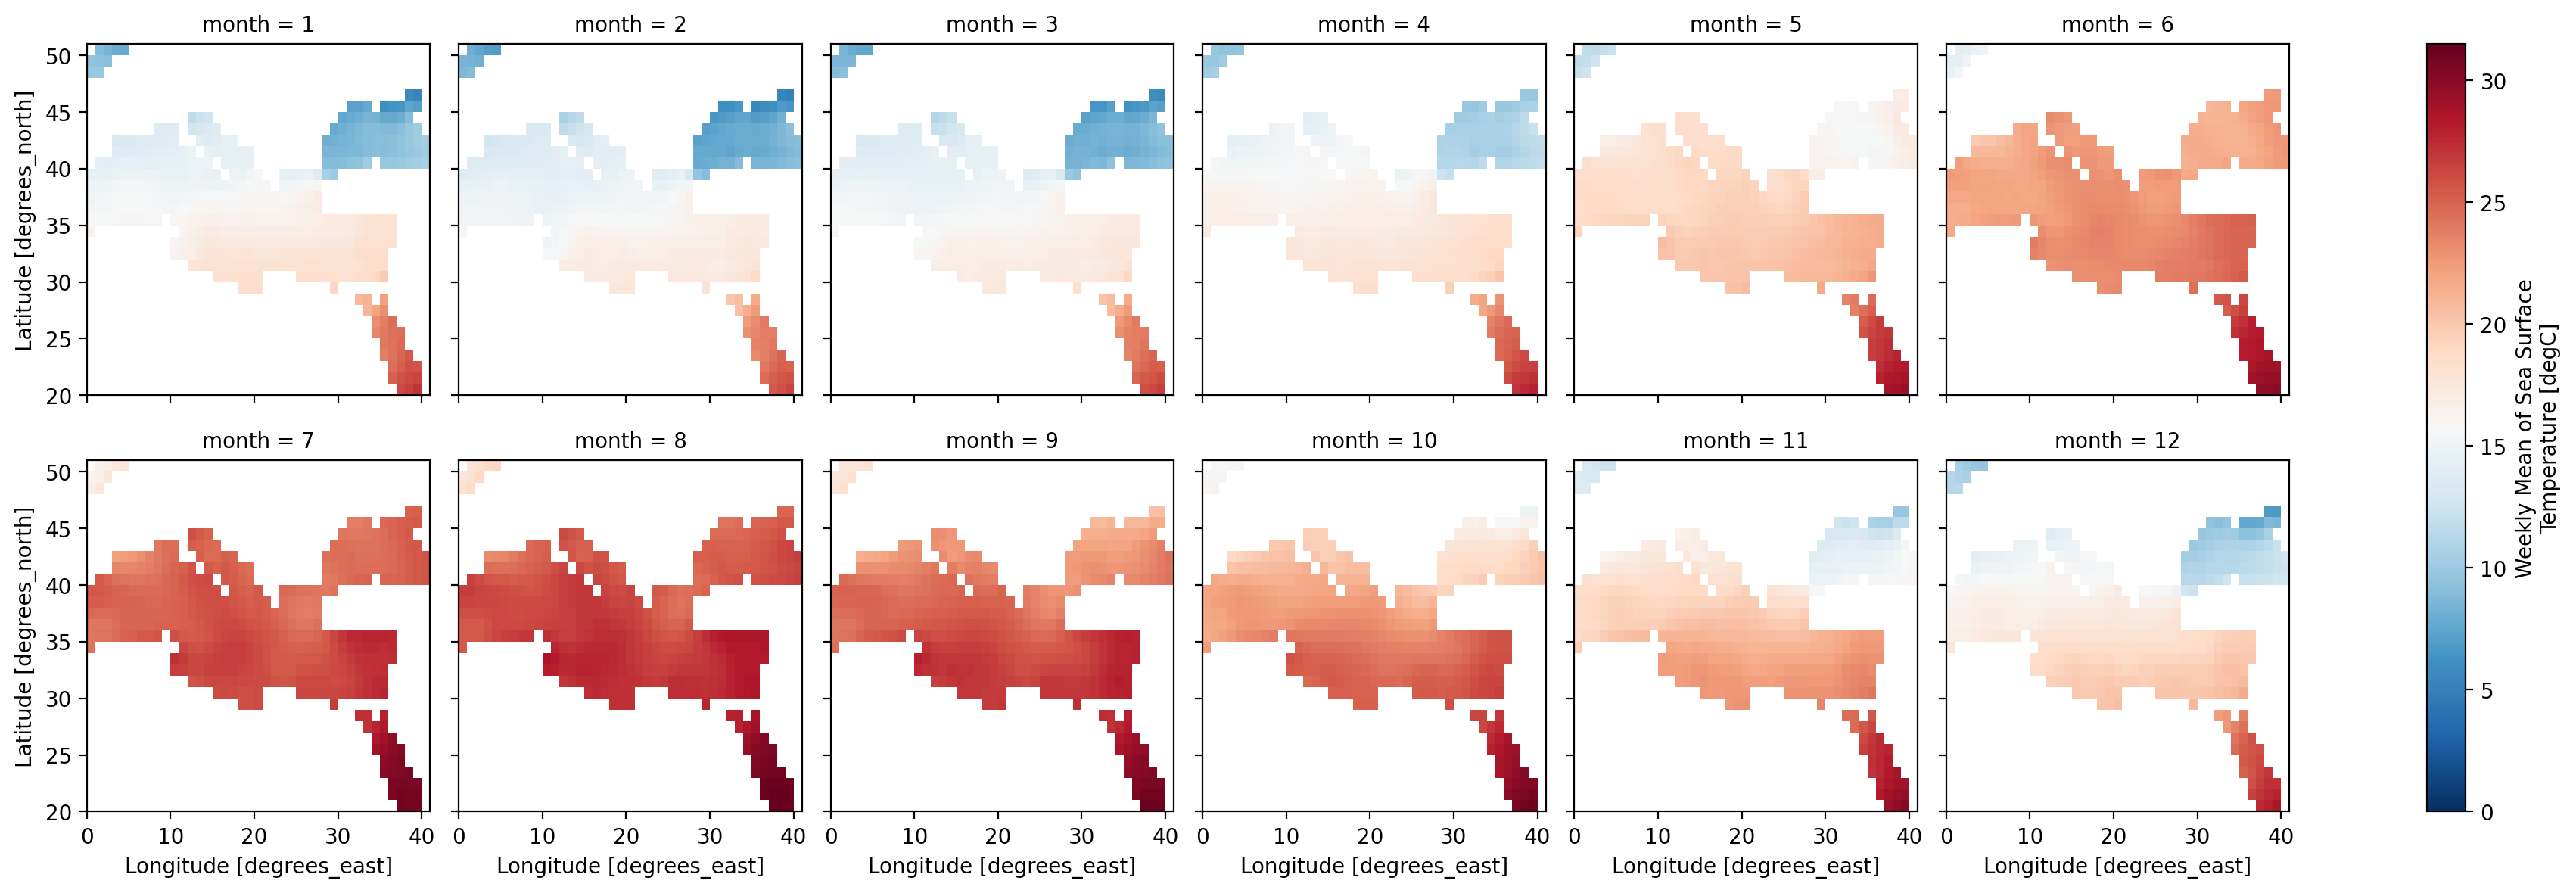

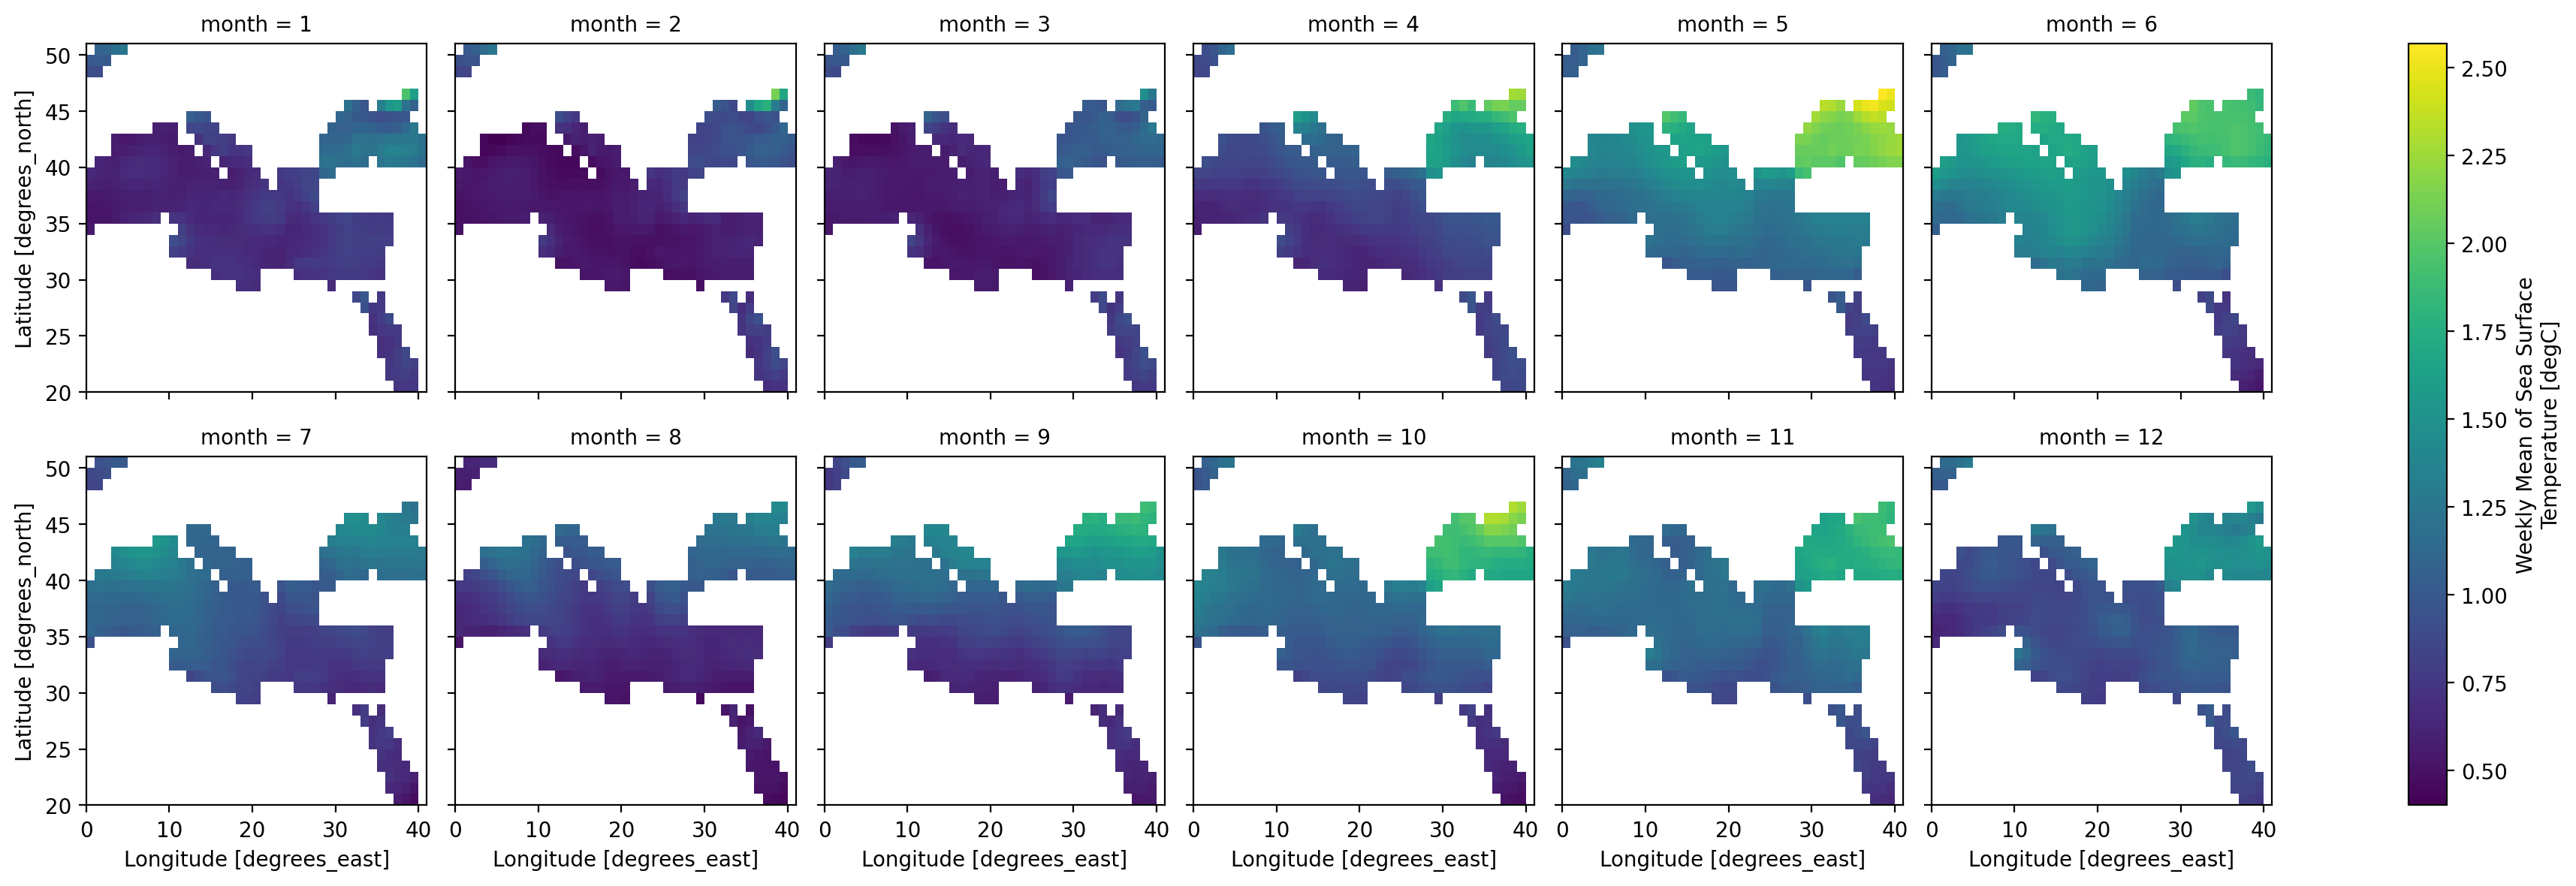

In [12]:
# January: 1 ... December: 12
print("Mean/Std Climatology per month over period 1992 - 2023")

tos_clim.plot(col='month', col_wrap=6, cmap='RdBu_r', vmin=0)

tos_std.plot(col='month', col_wrap=6)

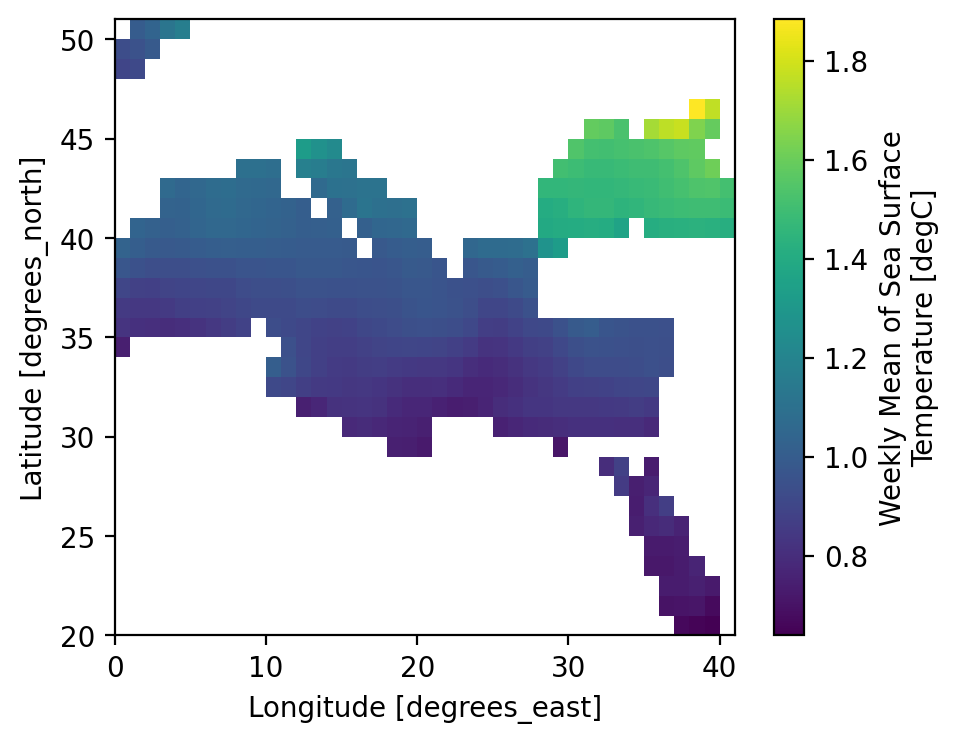

In [21]:
## The average interannual SST variability, averaged across months
# Each month contributes equally, regardless of winter/summer variability

# this would be the initial map displayed, allowing to click on region to display other metrics.
plt.figure(figsize=(5,4))
tos_std.mean(dim='month').plot()
# answer “Where is SST variable across years, on average over the seasonal cycle?”

2. Anomalies

In [22]:
# anomalies:
tos_anom = sst_gb - tos_clim
print(tos_anom.dims, tos_anom.shape)

('time', 'lat', 'lon') (1727, 31, 41)


In [25]:
# User click on one point on the map which selects coordinates. (to build)
sel_lat_idx, sel_lon_idx = 45, 35

Text(0.5, 0, 'Time (months)')

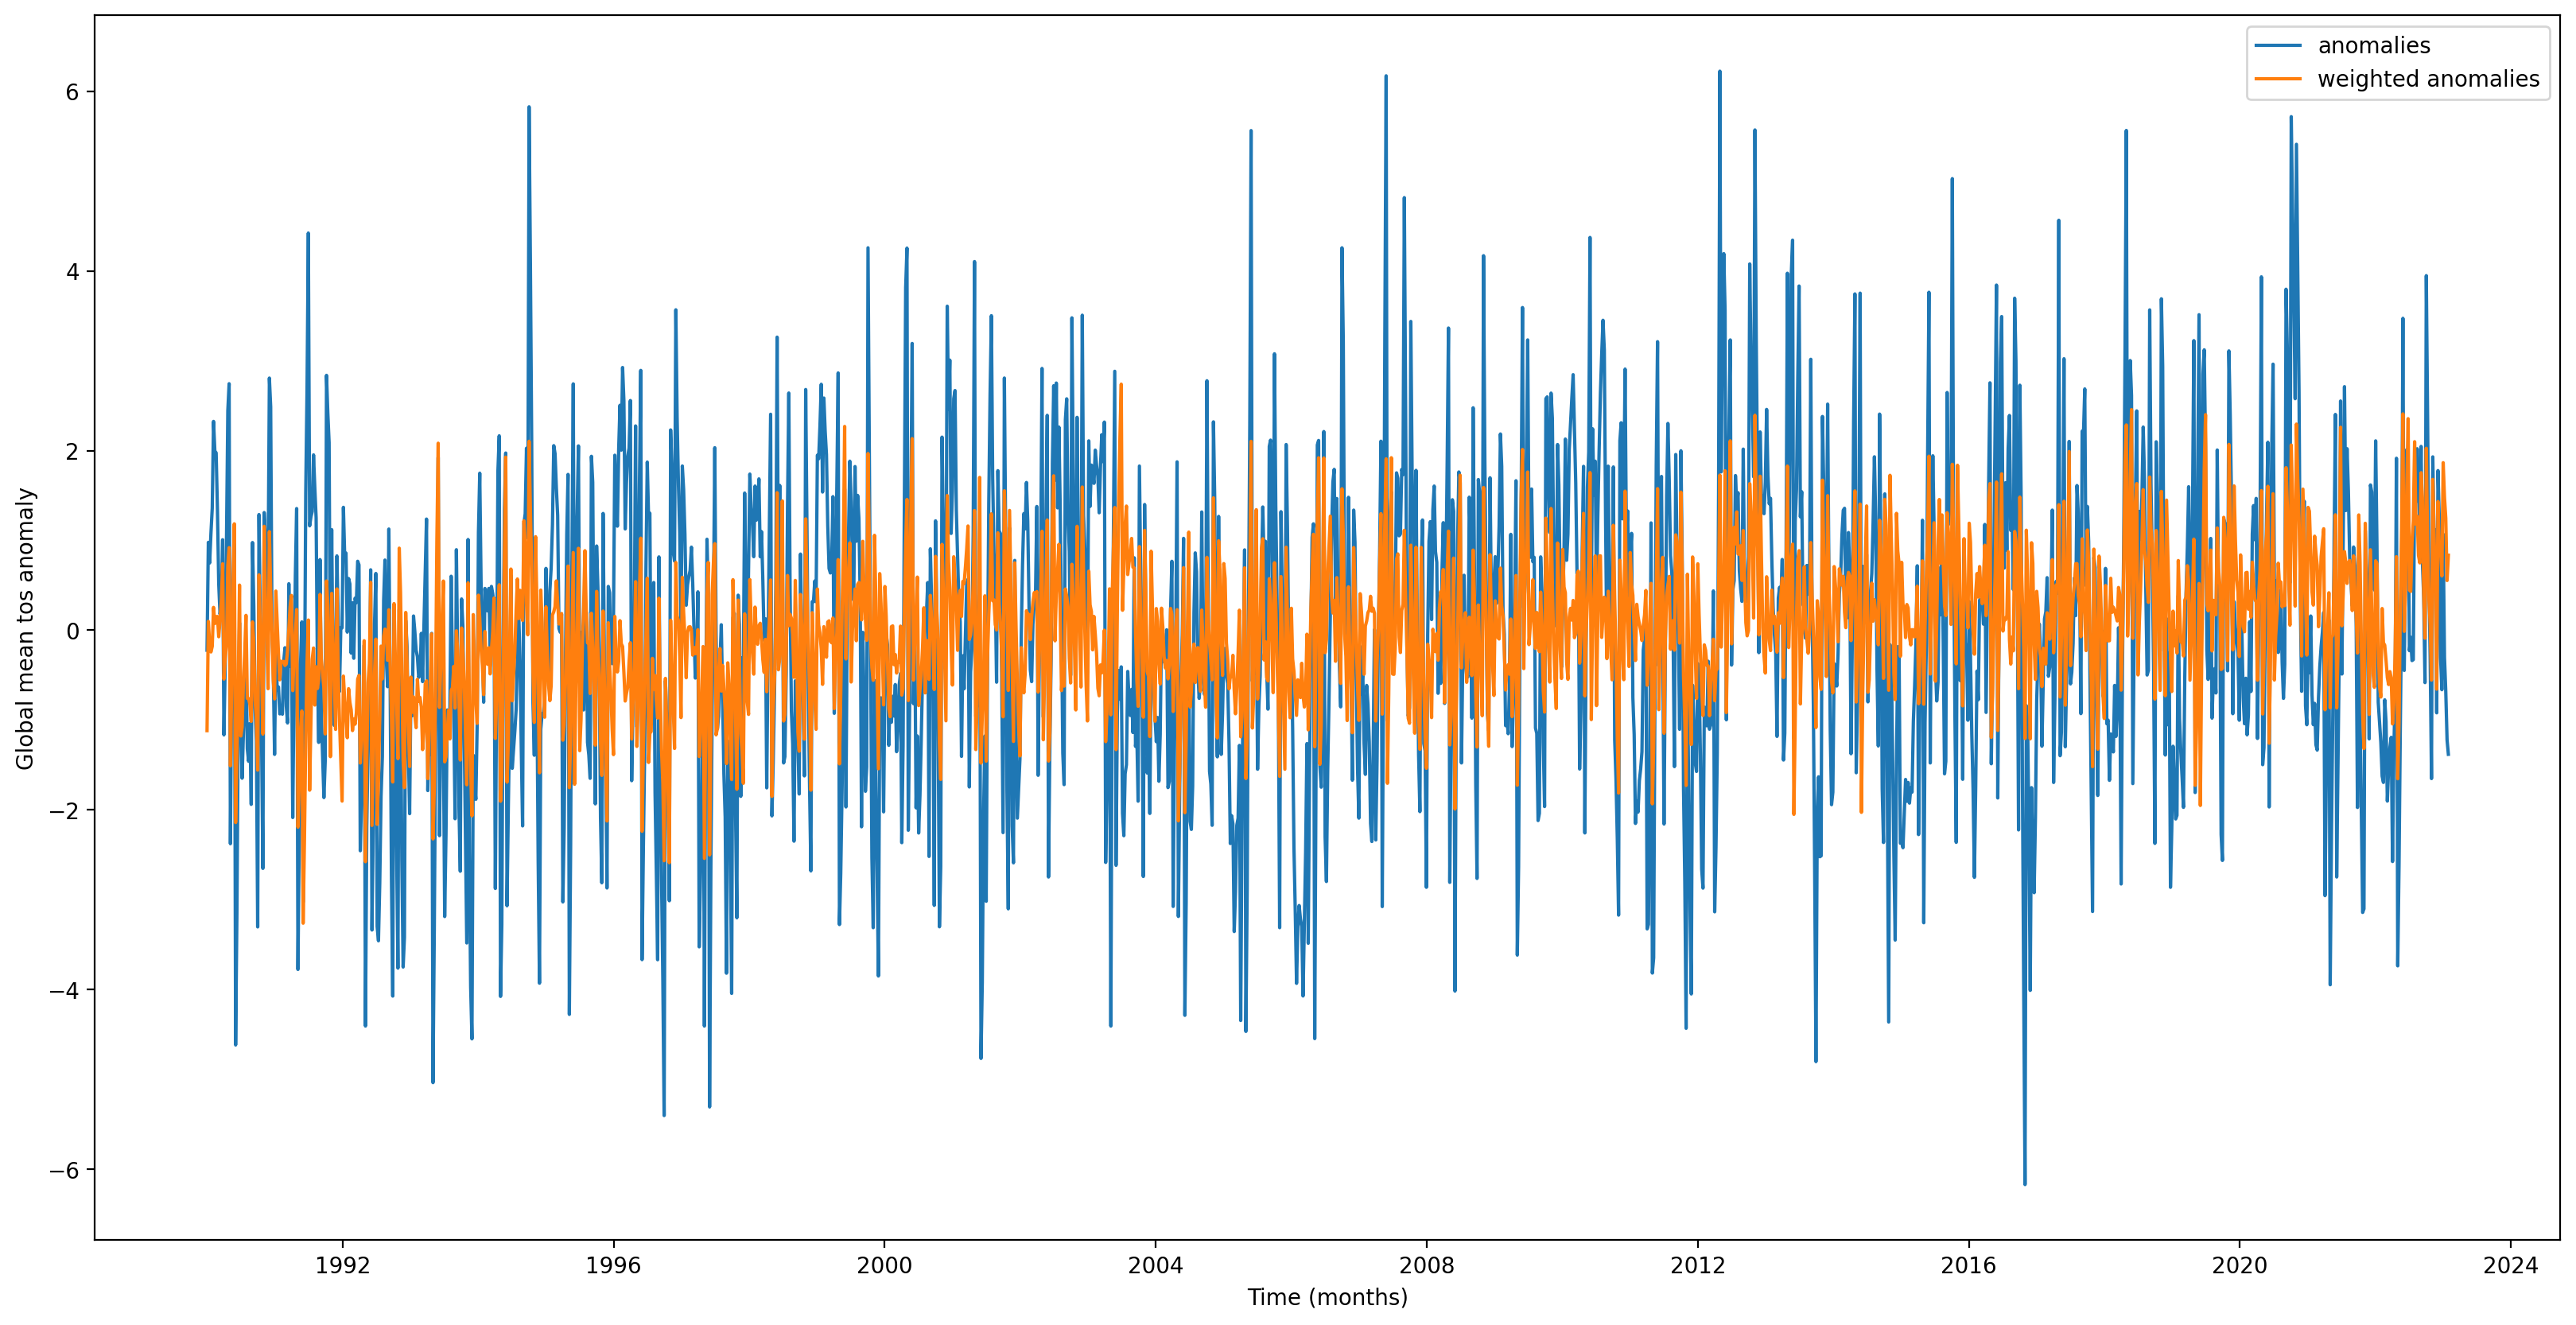

In [78]:
# step 2.1: Trend over years
plt.figure(figsize=(20,10))
tos_anom.sel(lon=sel_lon_idx, lat=sel_lat_idx, method="nearest").plot()

# RAW Data
weighted_anom = tos_anom.mean(dim=["lat", "lon"])
weighted_anom.plot()

plt.legend(["anomalies", "weighted anomalies"])
plt.ylabel("Global mean tos anomaly")
plt.xlabel("Time (months)")

In [73]:
# Linear regression (and others) don’t care about “dates”, need to change to meaningful scale
# standard is to convert time to decimal years

In [74]:
time_standardized = weighted_anom.time.dt.year + (weighted_anom.time.dt.dayofyear - 1) / 365.25

weighted_anom.time.values, time_standardized.values, weighted_anom.values

(array(['1989-12-31T00:00:00.000000000', '1990-01-07T00:00:00.000000000',
        '1990-01-14T00:00:00.000000000', ...,
        '2023-01-15T00:00:00.000000000', '2023-01-22T00:00:00.000000000',
        '2023-01-29T00:00:00.000000000'],
       shape=(1727,), dtype='datetime64[ns]'),
 array([1989.99657769, 1990.0164271 , 1990.03559206, ..., 2023.03832991,
        2023.05749487, 2023.07665982], shape=(1727,)),
 array([-1.1179543 ,  0.09832528, -0.15123892, ...,  1.2478666 ,
         0.5534859 ,  0.83529776], shape=(1727,), dtype=float32))

Text(0.5, 0, 'Time (months)')

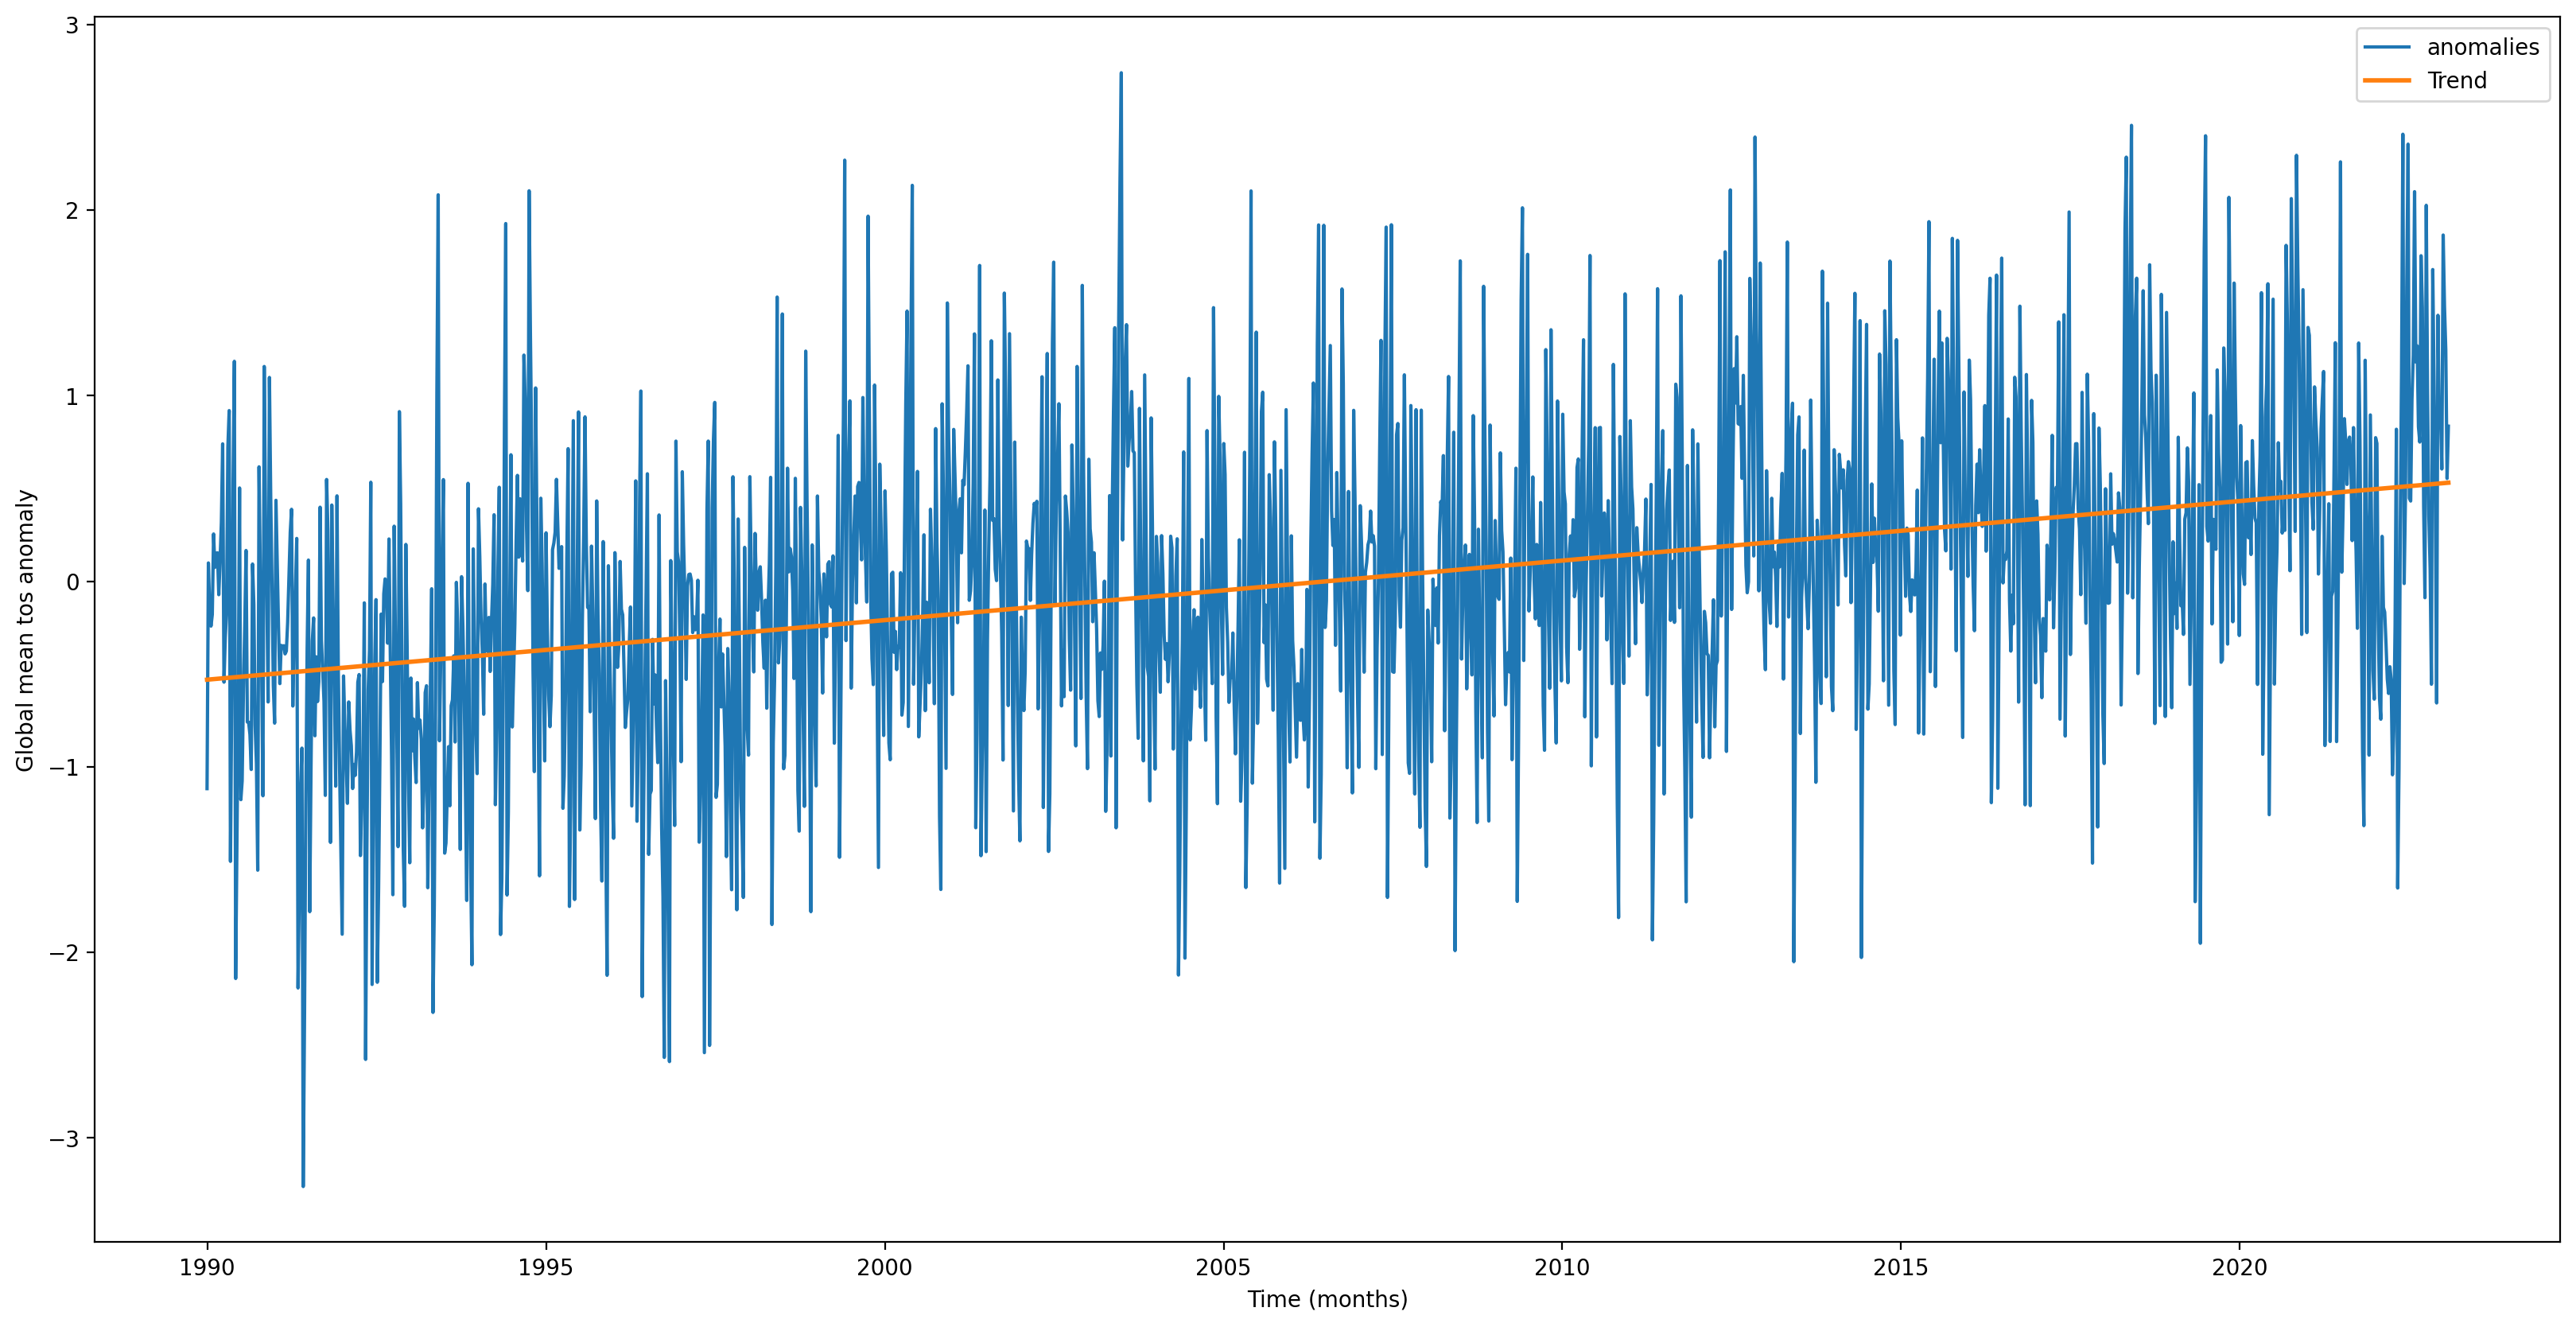

In [81]:
# a. OLS
X = np.array(anom_time_standardized.values).reshape(-1,1)
y = np.array(weighted_anom.values).reshape(-1,1)

reg = LinearRegression().fit(X, y)

plt.figure(figsize=(20,10))
plt.plot(X,y)
plt.plot(X, reg.predict(X), linewidth=2)

plt.legend(["anomalies", "Trend"])
plt.ylabel("Global mean tos anomaly")
plt.xlabel("Time (months)")